In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def extract_last_digit_from_login_id(login_username: str) -> int:
    """Extract the final numeric digit from a username like abc123."""
    if not isinstance(login_username, str):
        raise ValueError('Login ID must be a string username.')

    normalized_username = login_username.strip()
    if not re.fullmatch(r'[A-Za-z]+\d+', normalized_username):
        raise ValueError('Username format must be letters first, then numbers, e.g., epo0091.')

    return int(normalized_username[-1])


In [4]:
def resolve_execution_mode(login_username: str) -> str:
    last_digit = extract_last_digit_from_login_id(login_username)
    return 'single_layer_even' if last_digit % 2 == 0 else 'multilayer_odd'

In [5]:
def _draw_nodes_and_edges(axis, layer_positions, layer_labels, direction_label='Feed-forward direction'):
    for layer_index, x_position in enumerate(layer_positions):
        y_positions = np.linspace(0.9, 0.1, len(layer_positions[x_position]))
        layer_positions[x_position] = y_positions

    x_keys = list(layer_positions.keys())
    for left_index in range(len(x_keys) - 1):
        x_left = x_keys[left_index]
        x_right = x_keys[left_index + 1]
        for y_left in layer_positions[x_left]:
            for y_right in layer_positions[x_right]:
                axis.annotate('', xy=(x_right - 0.02, y_right), xytext=(x_left + 0.02, y_left),
                              arrowprops=dict(arrowstyle='->', lw=1.3, color='black'))

    for x_position, y_positions in layer_positions.items():
        for y_position in y_positions:
            axis.scatter(x_position, y_position, s=650, facecolor='#d9d9d9', edgecolor='black', zorder=3)

    for x_position, label in layer_labels.items():
        axis.text(x_position, -0.05, label, ha='center', va='top', fontsize=12, fontweight='bold')

    axis.annotate(direction_label, xy=(0.92, 1.02), xytext=(0.08, 1.02),
                  arrowprops=dict(arrowstyle='->', lw=1.5), ha='center', va='center', fontsize=11)
    axis.set_xlim(0, 1)
    axis.set_ylim(-0.1, 1.08)
    axis.axis('off')



In [6]:
def plot_single_layer_perceptron_diagram(input_neurons_count: int, output_neurons_count: int):
    figure, axis = plt.subplots(figsize=(10, 6))
    layer_positions = {
        0.15: [None] * input_neurons_count,
        0.85: [None] * output_neurons_count,
    }
    layer_labels = {
        0.15: 'Input layer of source nodes',
        0.85: 'Output layer of neurons'
    }
    _draw_nodes_and_edges(axis, layer_positions, layer_labels)
    axis.set_title('Single-layer Perceptron Architecture', fontsize=14, fontweight='bold')
    plt.show()

In [7]:
def plot_multilayer_feedforward_diagram(input_neurons_count: int, hidden_neurons_count: int, output_neurons_count: int):
    figure, axis = plt.subplots(figsize=(11, 7))
    layer_positions = {
        0.10: [None] * input_neurons_count,
        0.50: [None] * hidden_neurons_count,
        0.86: [None] * output_neurons_count,
    }
    layer_labels = {
        0.10: 'Input layer of source nodes',
        0.50: 'Layer of hidden neurons',
        0.86: 'Layer of output neurons'
    }
    _draw_nodes_and_edges(axis, layer_positions, layer_labels)
    axis.set_title('Multilayer Feed-forward Network Architecture', fontsize=14, fontweight='bold')
    plt.show()

In [9]:
class SingleLayerPerceptronLinearCombiner:
    def __init__(self, feature_count: int, learning_rate: float = 0.25):
        self.feature_count = feature_count
        self.learning_rate = learning_rate
        self.synaptic_weights = np.array([0.20, -0.10, 0.15, 0.05], dtype=float)
        self.bias_value = -0.05

    @staticmethod
    def threshold_activation_function(net_input_value: float) -> int:
        return 1 if net_input_value >= 0 else 0

    def forward(self, input_vector: np.ndarray):
        net_input_value = np.dot(input_vector, self.synaptic_weights) + self.bias_value
        output_value = self.threshold_activation_function(net_input_value)
        return net_input_value, output_value

    def fit(self, input_matrix: np.ndarray, target_vector: np.ndarray, total_iterations: int = 3):
        adjustment_history = []

        for iteration_index in range(1, total_iterations + 1):
            total_absolute_error = 0
            for sample_index, (input_vector, expected_output) in enumerate(zip(input_matrix, target_vector), start=1):
                _, predicted_output = self.forward(input_vector)
                error_value = expected_output - predicted_output
                total_absolute_error += abs(error_value)

                self.synaptic_weights = self.synaptic_weights + self.learning_rate * error_value * input_vector
                self.bias_value = self.bias_value + self.learning_rate * error_value

                adjustment_history.append({
                    'iteration': iteration_index,
                    'sample_number': sample_index,
                    'error_value': error_value,
                    'weight_1': round(self.synaptic_weights[0], 4),
                    'weight_2': round(self.synaptic_weights[1], 4),
                    'weight_3': round(self.synaptic_weights[2], 4),
                    'weight_4': round(self.synaptic_weights[3], 4),
                    'bias_value': round(self.bias_value, 4),
                    'total_absolute_error_for_iteration': total_absolute_error
                })

        return pd.DataFrame(adjustment_history)

In [10]:
def build_single_layer_original_dataset():
    input_matrix = np.array([
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [1, 1, 0, 1],
        [0, 0, 1, 1],
        [1, 0, 0, 1],
        [0, 1, 0, 1],
    ], dtype=float)
    target_vector = np.array([1, 0, 1, 0, 1, 0], dtype=int)
    feature_names = ['x_temperature', 'x_pressure', 'x_humidity', 'x_wind']

    dataset_table = pd.DataFrame(input_matrix, columns=feature_names)
    dataset_table['target_output'] = target_vector
    return input_matrix, target_vector, dataset_table




In [11]:
def run_single_layer_experiment(student_full_name: str):
    print(f'Running single-layer perceptron for: {student_full_name}')

    input_matrix, target_vector, dataset_table = build_single_layer_original_dataset()
    print('Original single-layer dataset:')
    display(dataset_table)

    single_layer_network = SingleLayerPerceptronLinearCombiner(feature_count=input_matrix.shape[1], learning_rate=0.20)

    first_input_vector = input_matrix[0]
    first_net_input, first_output = single_layer_network.forward(first_input_vector)
    print('Initial synaptic weights:', np.round(single_layer_network.synaptic_weights, 4))
    print('Initial bias value:', round(single_layer_network.bias_value, 4))
    print('Activation function: Threshold')
    print('Forward-pass demonstration on first input vector:', first_input_vector)
    print('Net input value:', round(first_net_input, 4))
    print('Output value:', first_output)

    weight_adjustment_table = single_layer_network.fit(input_matrix, target_vector, total_iterations=3)
    print('Weight adjustment table (at least 3 iterations):')
    display(weight_adjustment_table)

    plot_single_layer_perceptron_diagram(input_neurons_count=input_matrix.shape[1], output_neurons_count=4)

    return {
        'dataset_table': dataset_table,
        'weight_adjustment_table': weight_adjustment_table,
        'final_weights': single_layer_network.synaptic_weights,
        'final_bias': single_layer_network.bias_value
    }

In [12]:
class MultilayerFeedForwardNetworkModel:
    def __init__(self, input_size: int, hidden_size_1: int, hidden_size_2: int, output_size: int, random_seed: int = 11):
        np.random.seed(random_seed)
        self.weights_input_hidden_1 = np.random.uniform(-0.6, 0.6, (input_size, hidden_size_1))
        self.bias_hidden_1 = np.zeros((1, hidden_size_1))

        self.weights_hidden_1_hidden_2 = np.random.uniform(-0.6, 0.6, (hidden_size_1, hidden_size_2))
        self.bias_hidden_2 = np.zeros((1, hidden_size_2))

        self.weights_hidden_2_output = np.random.uniform(-0.6, 0.6, (hidden_size_2, output_size))
        self.bias_output = np.zeros((1, output_size))

    @staticmethod
    def sigmoid(value):
        return 1.0 / (1.0 + np.exp(-value))

    @staticmethod
    def sigmoid_derivative(activated_value):
        return activated_value * (1.0 - activated_value)

    def forward(self, input_matrix):
        self.hidden_layer_1_input = np.dot(input_matrix, self.weights_input_hidden_1) + self.bias_hidden_1
        self.hidden_layer_1_output = self.sigmoid(self.hidden_layer_1_input)

        self.hidden_layer_2_input = np.dot(self.hidden_layer_1_output, self.weights_hidden_1_hidden_2) + self.bias_hidden_2
        self.hidden_layer_2_output = self.sigmoid(self.hidden_layer_2_input)

        self.output_layer_input = np.dot(self.hidden_layer_2_output, self.weights_hidden_2_output) + self.bias_output
        self.output_layer_output = self.sigmoid(self.output_layer_input)
        return self.output_layer_output

    def train(self, input_matrix, target_matrix, learning_rate=0.35, iterations=2500):
        training_progress = []

        for iteration_number in range(1, iterations + 1):
            predicted_matrix = self.forward(input_matrix)
            output_error = target_matrix - predicted_matrix
            mean_squared_error = np.mean(output_error ** 2)

            gradient_output = output_error * self.sigmoid_derivative(predicted_matrix)
            gradient_hidden_2 = np.dot(gradient_output, self.weights_hidden_2_output.T) * self.sigmoid_derivative(self.hidden_layer_2_output)
            gradient_hidden_1 = np.dot(gradient_hidden_2, self.weights_hidden_1_hidden_2.T) * self.sigmoid_derivative(self.hidden_layer_1_output)

            self.weights_hidden_2_output += np.dot(self.hidden_layer_2_output.T, gradient_output) * learning_rate
            self.bias_output += np.sum(gradient_output, axis=0, keepdims=True) * learning_rate

            self.weights_hidden_1_hidden_2 += np.dot(self.hidden_layer_1_output.T, gradient_hidden_2) * learning_rate
            self.bias_hidden_2 += np.sum(gradient_hidden_2, axis=0, keepdims=True) * learning_rate

            self.weights_input_hidden_1 += np.dot(input_matrix.T, gradient_hidden_1) * learning_rate
            self.bias_hidden_1 += np.sum(gradient_hidden_1, axis=0, keepdims=True) * learning_rate

            if iteration_number % 250 == 0 or iteration_number == 1 or iteration_number == iterations:
                training_progress.append({
                    'iteration_number': iteration_number,
                    'mean_squared_error': float(mean_squared_error)
                })

        return pd.DataFrame(training_progress)

In [13]:
def build_multilayer_original_dataset():
    input_matrix = np.array([
        [0, 0, 1, 0, 1],
        [0, 1, 1, 0, 0],
        [1, 0, 1, 1, 0],
        [1, 1, 0, 1, 1],
        [1, 0, 0, 1, 1],
        [0, 1, 0, 1, 1],
        [1, 1, 1, 0, 1],
        [0, 0, 0, 1, 0],
    ], dtype=float)

    target_matrix = np.array([
        [1, 0],
        [1, 0],
        [0, 1],
        [0, 1],
        [0, 1],
        [1, 0],
        [0, 1],
        [1, 0],
    ], dtype=float)

    input_feature_names = ['x_sensor_1', 'x_sensor_2', 'x_sensor_3', 'x_sensor_4', 'x_sensor_5']
    target_feature_names = ['y_class_A', 'y_class_B']

    dataset_table = pd.DataFrame(input_matrix, columns=input_feature_names)
    for output_index, target_name in enumerate(target_feature_names):
        dataset_table[target_name] = target_matrix[:, output_index]

    return input_matrix, target_matrix, dataset_table


def run_multilayer_experiment(student_full_name: str):
    print(f'Running multilayer feed-forward network for: {student_full_name}')

    input_matrix, target_matrix, dataset_table = build_multilayer_original_dataset()
    print('Expanded multilayer dataset:')
    display(dataset_table)

    multilayer_network = MultilayerFeedForwardNetworkModel(
        input_size=input_matrix.shape[1],
        hidden_size_1=6,
        hidden_size_2=4,
        output_size=target_matrix.shape[1],
        random_seed=42
    )

    training_table = multilayer_network.train(input_matrix, target_matrix, learning_rate=0.35, iterations=2500)

    print('Training progress (start to finish snapshot):')
    display(training_table)

    final_predictions = multilayer_network.forward(input_matrix)
    final_predictions_table = pd.DataFrame(np.round(final_predictions, 4), columns=['predicted_class_A', 'predicted_class_B'])
    print('Final model predictions:')
    display(final_predictions_table)

    plot_multilayer_feedforward_diagram(input_neurons_count=input_matrix.shape[1], hidden_neurons_count=4, output_neurons_count=2)

    return {
        'dataset_table': dataset_table,
        'training_table': training_table,
        'final_predictions_table': final_predictions_table
    }

Last digit detected: 4
Even last digit -> executing single-layer feed-forward network task.
Running single-layer perceptron for: Student Full Name
Original single-layer dataset:


,x_temperature,x_pressure,x_humidity,x_wind,target_output
0,1.0,0.0,1.0,0.0,1
1,0.0,1.0,1.0,0.0,0
2,1.0,1.0,0.0,1.0,1
3,0.0,0.0,1.0,1.0,0
4,1.0,0.0,0.0,1.0,1
5,0.0,1.0,0.0,1.0,0


Initial synaptic weights: [ 0.2  -0.1   0.15  0.05]
Initial bias value: -0.05
Activation function: Threshold
Forward-pass demonstration on first input vector: [1. 0. 1. 0.]
Net input value: 0.3
Output value: 1
Weight adjustment table (at least 3 iterations):


,iteration,sample_number,error_value,weight_1,weight_2,weight_3,weight_4,bias_value,total_absolute_error_for_iteration
0,1,1,0,0.2,-0.1,0.15,0.05,-0.05,0
1,1,2,0,0.2,-0.1,0.15,0.05,-0.05,0
2,1,3,0,0.2,-0.1,0.15,0.05,-0.05,0
3,1,4,-1,0.2,-0.1,-0.05,-0.15,-0.25,1
4,1,5,1,0.4,-0.1,-0.05,0.05,-0.05,2
5,1,6,0,0.4,-0.1,-0.05,0.05,-0.05,2
6,2,1,0,0.4,-0.1,-0.05,0.05,-0.05,0
7,2,2,0,0.4,-0.1,-0.05,0.05,-0.05,0
8,2,3,0,0.4,-0.1,-0.05,0.05,-0.05,0
9,2,4,0,0.4,-0.1,-0.05,0.05,-0.05,0


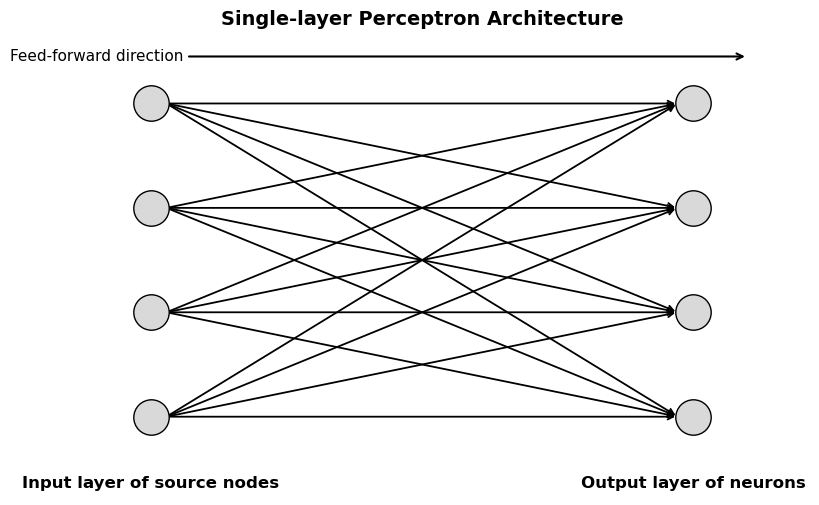

Execution completed from start to finish.


In [14]:
student_full_name = 'Student Full Name'
try:
    login_id_username = input('Enter login ID username (letters first then numbers, e.g., epo0091): ').strip()
except Exception:
    login_id_username = 'epo0373'
    print('No interactive input detected. Using default login ID: epo0091')

if not login_id_username:
    login_id_username = 'epo0091'
    print('Empty input detected. Using default login ID: epo0091')

execution_mode = resolve_execution_mode(login_id_username)
print(f'Last digit detected: {extract_last_digit_from_login_id(login_id_username)}')

if execution_mode == 'single_layer_even':
    print('Even last digit -> executing single-layer feed-forward network task.')
    experiment_outputs = run_single_layer_experiment(student_full_name=student_full_name)
else:
    print('Odd last digit -> executing multilayer feed-forward network task.')
    experiment_outputs = run_multilayer_experiment(student_full_name=student_full_name)

print('Execution completed from start to finish.')